# Test all trained YOLOv5 models on the test set / 在 test 集上测试所有已训练模型

## English
This notebook automatically scans every training experiment under `yolov5/runs/train/`, collects `best.pt` and `last.pt`, evaluates them on the **test** split with `val.py`, runs `detect.py` for visualization, and displays some prediction images.

## 中文
本 notebook 会自动遍历 `yolov5/runs/train/` 下的所有训练实验，收集每个实验中的 `best.pt` 和 `last.pt`，然后在 **test** 数据集上使用 `val.py` 做评估，再使用 `detect.py` 生成可视化结果，并展示部分预测图片。


## 1. Define core paths / 定义核心路径

This cell defines the project root, YOLOv5 root, dataset yaml path, and training runs directory.

本 cell 定义项目根目录、YOLOv5 根目录、数据集 yaml 路径，以及训练结果目录。


In [17]:
from pathlib import Path
import subprocess
import os
from datetime import datetime
import sys

import yaml
from PIL import Image
import matplotlib.pyplot as plt

# 项目根目录 / project root
PROJECT_ROOT = Path('/workspace/dl_project/project_yolov5')
# YOLOv5 根目录 / YOLOv5 root
YOLO_ROOT = PROJECT_ROOT / 'yolov5'
# 数据配置文件 / dataset yaml
DATA_YAML = YOLO_ROOT / 'data' / 'StudentWatch.yaml'
# 训练实验输出目录 / training runs directory
TRAIN_RUNS_DIR = YOLO_ROOT / 'runs' / 'train'
# 时间戳，用于避免输出目录重名 / timestamp for unique output folders
RUN_TAG = datetime.now().strftime('%Y%m%d_%H%M%S')
PYTHON_EXEC = sys.executable

PROJECT_ROOT, YOLO_ROOT, DATA_YAML, TRAIN_RUNS_DIR, PYTHON_EXEC


(PosixPath('/workspace/dl_project/project_yolov5'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml'),
 PosixPath('/workspace/dl_project/project_yolov5/yolov5/runs/train'),
 '/opt/conda/bin/python')

## 2. Check key paths / 检查关键路径

This cell ensures that the main project paths already exist before testing starts.

本 cell 用于确认测试开始前，几个关键路径都已经存在。


In [18]:
assert PROJECT_ROOT.exists(), f"PROJECT_ROOT not found: {PROJECT_ROOT}"
assert YOLO_ROOT.exists(), f"YOLO_ROOT not found: {YOLO_ROOT}"
assert DATA_YAML.exists(), f"DATA_YAML not found: {DATA_YAML}"
assert TRAIN_RUNS_DIR.exists(), f"TRAIN_RUNS_DIR not found: {TRAIN_RUNS_DIR}"
print('All key paths exist. / 关键路径检查通过。')


All key paths exist. / 关键路径检查通过。


## 3. Read dataset yaml and resolve test images path / 读取数据配置并解析 test 图片路径

This cell reads `StudentWatch.yaml`, extracts `path` and `test`, and builds the absolute path to the test images directory.

本 cell 读取 `StudentWatch.yaml`，解析其中的 `path` 和 `test` 字段，并拼接出 test 图片目录的绝对路径。


In [19]:
with open(DATA_YAML, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

# 数据根目录 / dataset root
data_root = Path(data_cfg['path'])
# test 字段中的相对路径 / relative test path from yaml
test_rel = data_cfg['test']
# test 图片绝对路径 / absolute test images directory
test_images_dir = (data_root / test_rel).resolve()

assert data_root.exists(), f'data root not found: {data_root}'
assert test_images_dir.exists(), f'test images dir not found: {test_images_dir}'

print('data root   :', data_root)
print('test field  :', test_rel)
print('test images :', test_images_dir)


data root   : /workspace/dl_project/project_yolov5/dataset/yolov5/sb
test field  : test/images
test images : /workspace/dl_project/project_yolov5/dataset/yolov5/sb/test/images


## 4. Switch to YOLOv5 root / 切换到 YOLOv5 根目录

This makes sure `val.py` and `detect.py` are run from the correct working directory.

这一步确保后续执行 `val.py` 和 `detect.py` 时，当前工作目录是正确的 YOLOv5 根目录。


In [20]:
os.chdir(YOLO_ROOT)
print('Current working directory / 当前工作目录:', Path.cwd())


Current working directory / 当前工作目录: /workspace/dl_project/project_yolov5/yolov5


## 5. Collect all available weights / 收集所有可用权重

This cell scans each experiment under `runs/train/*` and collects `weights/best.pt` and `weights/last.pt` if they exist.

本 cell 会遍历 `runs/train/*` 下的每个实验目录，自动收集存在的 `weights/best.pt` 和 `weights/last.pt`。


In [21]:
weight_jobs = []
skipped_jobs = []

# 仅评估 StudentWatch 相关实验
# Only evaluate StudentWatch-related experiments.
allowed_data_yamls = {
    (YOLO_ROOT / "data" / "StudentWatch.yaml").resolve(),
    (YOLO_ROOT / "data" / "StudentWatch_no_hr.yaml").resolve(),
}

# 遍历所有训练实验目录 / iterate over all training experiment folders
for exp_dir in sorted(TRAIN_RUNS_DIR.iterdir()):
    if not exp_dir.is_dir():
        continue

    weights_dir = exp_dir / "weights"
    if not weights_dir.exists():
        continue

    # 优先读取该实验自己的 opt.yaml，从中拿到训练时使用的 data 配置
    # Prefer each experiment's own opt.yaml so evaluation uses the matching dataset yaml.
    opt_yaml = exp_dir / "opt.yaml"
    if opt_yaml.exists():
        with open(opt_yaml, 'r', encoding='utf-8') as f:
            opt_cfg = yaml.safe_load(f)
        data_yaml_for_exp = Path(opt_cfg.get('data', DATA_YAML))
        if not data_yaml_for_exp.is_absolute():
            data_yaml_for_exp = (YOLO_ROOT / data_yaml_for_exp).resolve()
    else:
        data_yaml_for_exp = DATA_YAML.resolve()

    data_yaml_for_exp = data_yaml_for_exp.resolve()

    if data_yaml_for_exp not in allowed_data_yamls:
        skipped_jobs.append({
            "exp_name": exp_dir.name,
            "reason": f"unsupported data yaml: {data_yaml_for_exp}",
        })
        continue

    assert data_yaml_for_exp.exists(), f"data yaml not found for {exp_dir.name}: {data_yaml_for_exp}"

    with open(data_yaml_for_exp, 'r', encoding='utf-8') as f:
        exp_data_cfg = yaml.safe_load(f)

    # 优先使用 test；如果没有 test，则回退到 val，并打印提示
    # Prefer test split; if test is missing, fallback to val with a clear note.
    split_key = 'test' if 'test' in exp_data_cfg else 'val'
    exp_data_root = Path(exp_data_cfg['path'])
    exp_test_images_dir = (exp_data_root / exp_data_cfg[split_key]).resolve()

    assert exp_data_root.exists(), f"data root not found for {exp_dir.name}: {exp_data_root}"
    assert exp_test_images_dir.exists(), f"{split_key} images dir not found for {exp_dir.name}: {exp_test_images_dir}"

    # 同时检查 best.pt 和 last.pt / check both best.pt and last.pt
    for weight_name in ["best.pt", "last.pt"]:
        weight_path = weights_dir / weight_name
        if weight_path.exists():
            weight_jobs.append({
                "exp_name": exp_dir.name,
                "weight_type": weight_name.replace(".pt", ""),
                "weight_path": weight_path.resolve(),
                "data_yaml": data_yaml_for_exp,
                "test_images_dir": exp_test_images_dir,
                "split_key": split_key,
            })

assert weight_jobs, "No compatible best.pt or last.pt weights found under runs/train."

print(f"Collected {len(weight_jobs)} compatible weight files / 共收集到 {len(weight_jobs)} 个可测试权重文件:")
for job in weight_jobs:
    print(
        f"- {job['exp_name']} | {job['weight_type']} | {job['weight_path']} | data={job['data_yaml']} | split={job['split_key']}"
    )

if skipped_jobs:
    print("\nSkipped experiments / 已跳过的实验:")
    for item in skipped_jobs:
        print(f"- {item['exp_name']} | {item['reason']}")


Collected 30 compatible weight files / 共收集到 30 个可测试权重文件:
- no_hr_aug_weighted | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/best.pt | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml | split=test
- no_hr_aug_weighted | last | /workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/last.pt | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml | split=test
- sb_baseline | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_baseline/weights/best.pt | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml | split=test
- sb_baseline | last | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_baseline/weights/last.pt | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml | split=test
- sb_no_hr | best | /workspace/dl_project/project_yolov5/yolov5/runs/train/sb_no_hr/weights/best.pt | data=/workspace/dl_project/pr

## 6. Evaluate all weights with `val.py` on test split / 在 test 集上用 `val.py` 评估所有权重

This cell runs `python val.py` for every collected weight file, prints stdout/stderr, and stops immediately if any evaluation fails.

本 cell 会对每个收集到的权重依次执行 `python val.py`，打印 stdout/stderr；如果某个模型评估失败，会立刻抛出异常并停止。


In [22]:
val_results = []

for job in weight_jobs:
    # 为每个评估任务生成唯一目录名 / unique output folder name for each evaluation
    run_name = f"{job['exp_name']}_{job['weight_type']}_{RUN_TAG}"
    output_dir = YOLO_ROOT / "runs" / "test_eval" / run_name

    cmd = [
        str(PYTHON_EXEC), "val.py",
        "--data", str(job['data_yaml']),
        "--weights", str(job['weight_path']),
        "--img", "640",
        "--batch", "2",
        "--task", "test",
        "--project", "runs/test_eval",
        "--name", run_name,
        "--save-txt",
        "--save-conf",
        "--verbose",
    ]

    print("=" * 80)
    print("Running val.py for / 正在评估:", job['exp_name'], job['weight_type'])
    print("Data yaml / 数据配置:", job['data_yaml'])
    print("Eval split / 使用划分:", job['split_key'])
    print("Command / 命令:", " ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=YOLO_ROOT)

    print("----- STDOUT -----")
    print(result.stdout)
    print("----- STDERR -----")
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            f"val.py failed for {job['exp_name']} {job['weight_type']} with return code {result.returncode}"
        )

    val_results.append({
        **job,
        "run_name": run_name,
        "output_dir": output_dir,
        "stdout": result.stdout,
        "stderr": result.stderr,
    })


Running val.py for / 正在评估: no_hr_aug_weighted best
Data yaml / 数据配置: /workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml
Eval split / 使用划分: test
Command / 命令: /opt/conda/bin/python val.py --data /workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml --weights /workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/best.pt --img 640 --batch 2 --task test --project runs/test_eval --name no_hr_aug_weighted_best_20260409_061505 --save-txt --save-conf --verbose


----- STDOUT -----

----- STDERR -----
val: data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml, weights=['/workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/best.pt'], batch_size=2, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=, workers=8, single_cls=False, augment=False, verbose=True, save_txt=True, save_hybrid=False, save_conf=True, save_json=False, project=runs/test_eval, name=no_hr_aug_weighted_best_20260409_061505, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 2026-3-14 Python-3.10.13 torch-2.1.0 CUDA:0 (NVIDIA GeForce RTX 3090 Ti, 24245MiB)

Fusing layers... 
YOLOv5s_se summary: 169 layers, 7098154 parameters, 0 gradients, 15.9 GFLOPs

test: Scanning /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/labels.cache... 33 images, 0 backgrounds, 0 corrupt: 100%|██████████| 33/33 [00:00<?, ?it/s]
test: Scanning /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/labels

## 7. Show validation output directories / 打印评估输出目录

This cell lists all `runs/test_eval/...` output folders generated in the previous step.

本 cell 打印上一步生成的所有 `runs/test_eval/...` 评估结果目录。


In [23]:
print('Validation output directories / 评估输出目录:')
for item in val_results:
    print(
        f"- {item['exp_name']} ({item['weight_type']}): {item['output_dir']} | data={item['data_yaml']} | split={item['split_key']}"
    )


Validation output directories / 评估输出目录:
- no_hr_aug_weighted (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_eval/no_hr_aug_weighted_best_20260409_061505 | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml | split=test
- no_hr_aug_weighted (last): /workspace/dl_project/project_yolov5/yolov5/runs/test_eval/no_hr_aug_weighted_last_20260409_061505 | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch_no_hr.yaml | split=test
- sb_baseline (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_eval/sb_baseline_best_20260409_061505 | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml | split=test
- sb_baseline (last): /workspace/dl_project/project_yolov5/yolov5/runs/test_eval/sb_baseline_last_20260409_061505 | data=/workspace/dl_project/project_yolov5/yolov5/data/StudentWatch.yaml | split=test
- sb_no_hr (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_eval/sb_no_hr_best_20260409_061505 | data=/

In [24]:
performance_rows = []

def extract_all_metrics(output_text):
    # 从 val.py 输出里找总体 all 行
    # Find the overall all row from val.py output.
    for line in output_text.splitlines():
        parts = line.strip().split()
        if len(parts) >= 7 and parts[0] == "all":
            try:
                return {
                    "P": float(parts[3]),
                    "R": float(parts[4]),
                    "mAP50": float(parts[5]),
                    "mAP50_95": float(parts[6]),
                }
            except ValueError:
                continue
    return None

for item in val_results:
    # val.py 的关键日志经常打印在 stderr，所以这里合并 stdout 和 stderr 一起解析
    # YOLOv5 often prints evaluation logs to stderr, so we parse both stdout and stderr together.
    combined_output = (item.get("stdout", "") or "") + "\n" + (item.get("stderr", "") or "")
    metrics = extract_all_metrics(combined_output)
    if metrics is None:
        print(f"Warning: could not parse metrics for {item['exp_name']} ({item['weight_type']})")
        continue

    performance_rows.append({
        "exp_name": item["exp_name"],
        "weight_type": item["weight_type"],
        "split": item["split_key"],
        "P": metrics["P"],
        "R": metrics["R"],
        "mAP50": metrics["mAP50"],
        "mAP50-95": metrics["mAP50_95"],
    })

assert performance_rows, "No model performance could be parsed from val.py outputs."

# 统一排序，后续各个分表和总表都复用这个结果
# Sort once so all sub-tables and the final table reuse the same ordering.
performance_rows = sorted(performance_rows, key=lambda x: x["mAP50-95"], reverse=True)


def print_performance_table(rows, title):
    print(title)
    if not rows:
        print("No rows / 没有可显示的结果")
        return

    header = f"{'model':<28} {'wt':<6} {'split':<6} {'P':>10} {'R':>10} {'mAP50':>10} {'mAP50-95':>12}"
    print(header)
    print("-" * len(header))
    for row in rows:
        print(
            f"{row['exp_name']:<28} {row['weight_type']:<6} {row['split']:<6} "
            f"{row['P']:>10.4f} {row['R']:>10.4f} {row['mAP50']:>10.4f} {row['mAP50-95']:>12.4f}"
        )


## 8.1 Baseline only / 仅 baseline 分表

This table shows only the original YOLOv5 baseline without dropping `hand_raising`.

这个表只展示原始 YOLOv5 baseline，也就是**没有删除 hand_raising 类别**的实验结果。


In [25]:
baseline_rows = [row for row in performance_rows if row["exp_name"] == "sb_baseline"]
print_performance_table(baseline_rows, "Baseline only / 仅 baseline")


Baseline only / 仅 baseline
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_baseline                  last   test       0.9230     0.7420     0.8310       0.6480
sb_baseline                  best   test       0.9160     0.7390     0.8310       0.6410


## 8.2 Imbalanced data methods / 解决 imbalanced data 的方法

This table shows non-SE methods for handling imbalanced data, such as dropping `hand_raising`, augmentation, weighted loss, and their combinations.

这个表展示**不使用 SE** 的类别不平衡处理方法，包括删除 `hand_raising`、数据增强、加权损失及其组合。


In [26]:
imbalance_rows = [
    row for row in performance_rows
    if row["exp_name"] in {"sb_no_hr", "sb_no_hr_aug", "sb_no_hr_weighted", "sb_no_hr_aug_weighted"}
]
print_performance_table(imbalance_rows, "Imbalanced data methods / 解决 imbalanced data 的方法")


Imbalanced data methods / 解决 imbalanced data 的方法
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_no_hr_weighted            last   test       0.9050     0.8960     0.9070       0.7150
sb_no_hr_weighted            best   test       0.8990     0.8880     0.9100       0.7120
sb_no_hr                     last   test       0.9090     0.8910     0.9060       0.7110
sb_no_hr                     best   test       0.9050     0.8920     0.9010       0.7060
sb_no_hr_aug_weighted        best   test       0.8980     0.9070     0.9150       0.7020
sb_no_hr_aug_weighted        last   test       0.9000     0.8970     0.9110       0.7010
sb_no_hr_aug                 best   test       0.9130     0.8920     0.9120       0.6990
sb_no_hr_aug                 last   test       0.9130     0.8890     0.9060       0.6970


## 8.3 SE + imbalanced data methods / SE + 各种 imbalanced data 方法

This table shows the original SE model combined with imbalance-handling methods.

这个表展示**原始 SE 版本**与各种类别不平衡处理方法结合后的结果。

### sb_se_p3_p4_p5_no_hr_weighted.nohup.log -> best（用于测试集）


In [27]:
se_imbalance_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_no_hr",
        "se_no_hr_aug",
        "se_no_hr_weighted",
        "no_hr_aug_weighted",
    }
]
print_performance_table(
    se_imbalance_rows,
    "SE + imbalanced data methods / SE + 各种 imbalanced data 方法",
)


SE + imbalanced data methods / SE + 各种 imbalanced data 方法
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
se_no_hr_weighted            best   test       0.9190     0.8680     0.9170       0.7020
sb_se_no_hr                  best   test       0.8940     0.9080     0.9110       0.7010
se_no_hr_weighted            last   test       0.9140     0.8790     0.9180       0.6990
sb_se_no_hr                  last   test       0.8980     0.8980     0.9120       0.6980
se_no_hr_aug                 best   test       0.9070     0.8930     0.9200       0.6940
no_hr_aug_weighted           best   test       0.9060     0.8970     0.9130       0.6900
no_hr_aug_weighted           last   test       0.9190     0.8860     0.9130       0.6890
se_no_hr_aug                 last   test       0.9230     0.8830     0.9130       0.6860


## 8.4 SE ablation / SE 插入位置消融

This table shows SE placement ablation experiments in backbone and head.

这个表展示 SE 在 backbone 和 head 不同位置插入时的消融实验结果。


In [28]:
se_ablation_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_p4_no_hr",
        "sb_se_p5_no_hr",
        "sb_se_p3_p4_p5_no_hr",
        "sb_se_head_p4_no_hr",
        "sb_se_head_p4_p5_no_hr",
    }
]
print_performance_table(se_ablation_rows, "SE ablation / SE 插入位置消融")


SE ablation / SE 插入位置消融
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_se_p3_p4_p5_no_hr         best   test       0.9230     0.8670     0.9150       0.7090
sb_se_p3_p4_p5_no_hr         last   test       0.9230     0.8670     0.9150       0.7090
sb_se_head_p4_no_hr          best   test       0.9020     0.8960     0.9120       0.7080
sb_se_head_p4_no_hr          last   test       0.9020     0.8950     0.9120       0.7070
sb_se_p4_no_hr               last   test       0.9100     0.8820     0.9130       0.7040
sb_se_p4_no_hr               best   test       0.9170     0.8760     0.9150       0.7030
sb_se_p5_no_hr               best   test       0.9120     0.8740     0.9060       0.7020
sb_se_p5_no_hr               last   test       0.9160     0.8760     0.9050       0.6990
sb_se_head_p4_p5_no_hr       last   test       0.8850     0.8870     0.9080       0.69

## 8.5 sb_se_p3_p4_p5_no_hr_weighted

Show both `best` and `last` for this experiment on test split.

该分表展示这个实验在测试集上的 `best` 和 `last` 结果。


In [29]:
se_ablation_rows = [
    row for row in performance_rows
    if row["exp_name"] in {
        "sb_se_p3_p4_p5_no_hr_weighted",
    }
]
print_performance_table(se_ablation_rows, "sb_se_p3_p4_p5_no_hr_weighted (best + last) / 该实验 best 与 last")


sb_se_p3_p4_p5_no_hr_weighted (best + last) / 该实验 best 与 last
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_se_p3_p4_p5_no_hr_weighted last   test       0.9270     0.8670     0.9190       0.7140
sb_se_p3_p4_p5_no_hr_weighted best   test       0.9240     0.8670     0.9190       0.7130


## 8.6 Overall summary / 所有模型总表

This is the full summary table for all tested models.

这是所有已测试模型的完整总表。


In [30]:
print_performance_table(performance_rows, "Overall summary / 所有模型总表")


Overall summary / 所有模型总表
model                        wt     split           P          R      mAP50     mAP50-95
----------------------------------------------------------------------------------------
sb_no_hr_weighted            last   test       0.9050     0.8960     0.9070       0.7150
sb_se_p3_p4_p5_no_hr_weighted last   test       0.9270     0.8670     0.9190       0.7140
sb_se_p3_p4_p5_no_hr_weighted best   test       0.9240     0.8670     0.9190       0.7130
sb_no_hr_weighted            best   test       0.8990     0.8880     0.9100       0.7120
sb_no_hr                     last   test       0.9090     0.8910     0.9060       0.7110
sb_se_p3_p4_p5_no_hr         best   test       0.9230     0.8670     0.9150       0.7090
sb_se_p3_p4_p5_no_hr         last   test       0.9230     0.8670     0.9150       0.7090
sb_se_head_p4_no_hr          best   test       0.9020     0.8960     0.9120       0.7080
sb_se_head_p4_no_hr          last   test       0.9020     0.8950     0.9120       0

## 10. Run `detect.py` for visualization / 用 `detect.py` 生成可视化结果

This cell runs `detect.py` for every collected weight using the resolved test image directory as input.

本 cell 会对每个收集到的权重执行 `detect.py`，并使用前面解析得到的 test 图片目录作为输入，生成检测可视化结果。


In [ ]:
detect_results = []

for job in weight_jobs:
    # 与评估步骤保持一致的命名方式 / keep the same naming rule as validation
    run_name = f"{job['exp_name']}_{job['weight_type']}_{RUN_TAG}"
    output_dir = YOLO_ROOT / "runs" / "test_detect" / run_name

    cmd = [
        str(PYTHON_EXEC), "detect.py",
        "--weights", str(job['weight_path']),
        "--source", str(job['test_images_dir']),
        "--img", "640",
        "--conf", "0.25",
        "--project", "runs/test_detect",
        "--name", run_name,
        "--save-txt",
        "--save-conf",
    ]

    print("=" * 80)
    print("Running detect.py for / 正在生成可视化:", job['exp_name'], job['weight_type'])
    print("Test images / 测试图片目录:", job['test_images_dir'])
    print("Eval split / 使用划分:", job['split_key'])
    print("Command / 命令:", " ".join(cmd))

    result = subprocess.run(cmd, capture_output=True, text=True, cwd=YOLO_ROOT)

    print("----- STDOUT -----")
    print(result.stdout)
    print("----- STDERR -----")
    print(result.stderr)

    if result.returncode != 0:
        raise RuntimeError(
            f"detect.py failed for {job['exp_name']} {job['weight_type']} with return code {result.returncode}"
        )

    detect_results.append({
        **job,
        "run_name": run_name,
        "output_dir": output_dir,
        "stdout": result.stdout,
        "stderr": result.stderr,
    })


Running detect.py for / 正在生成可视化: no_hr_aug_weighted best
Test images / 测试图片目录: /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images
Eval split / 使用划分: test
Command / 命令: /opt/conda/bin/python detect.py --weights /workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/best.pt --source /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images --img 640 --conf 0.25 --project runs/test_detect --name no_hr_aug_weighted_best_20260409_061505 --save-txt --save-conf


----- STDOUT -----

----- STDERR -----
detect: weights=['/workspace/dl_project/project_yolov5/yolov5/runs/train/no_hr_aug_weighted/weights/best.pt'], source=/workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/test_detect, name=no_hr_aug_weighted_best_20260409_061505, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 2026-3-14 Python-3.10.13 torch-2.1.0 CUDA:0 (NVIDIA GeForce RTX 3090 Ti, 24245MiB)

Fusing layers... 
YOLOv5s_se summary: 169 layers, 7098154 parameters, 0 gradients, 15.9 GFLOPs
image 1/33 /workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images/4001002_png.rf.50df76ccde4f78e90

## 11. Show detect output directories / 打印 detect 输出目录

This cell lists all `runs/test_detect/...` folders generated by `detect.py`.

本 cell 打印 `detect.py` 生成的所有 `runs/test_detect/...` 输出目录。


In [ ]:
print('Detect output directories / 可视化输出目录:')
for item in detect_results:
    print(
        f"- {item['exp_name']} ({item['weight_type']}): {item['output_dir']} | source={item['test_images_dir']} | split={item['split_key']}"
    )


Detect output directories / 可视化输出目录:
- no_hr_aug_weighted (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_detect/no_hr_aug_weighted_best_20260409_060538 | source=/workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images | split=test
- no_hr_aug_weighted (last): /workspace/dl_project/project_yolov5/yolov5/runs/test_detect/no_hr_aug_weighted_last_20260409_060538 | source=/workspace/dl_project/project_yolov5/dataset/yolov5/sb_no_hr/test/images | split=test
- sb_baseline (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_detect/sb_baseline_best_20260409_060538 | source=/workspace/dl_project/project_yolov5/dataset/yolov5/sb/test/images | split=test
- sb_baseline (last): /workspace/dl_project/project_yolov5/yolov5/runs/test_detect/sb_baseline_last_20260409_060538 | source=/workspace/dl_project/project_yolov5/dataset/yolov5/sb/test/images | split=test
- sb_no_hr (best): /workspace/dl_project/project_yolov5/yolov5/runs/test_detect/sb_no_hr_best_20260409_

## 12. Visualize some prediction images / 展示部分预测图片

This cell reads several prediction images from the detect output folders and shows them with matplotlib.

本 cell 会从 detect 生成的预测结果目录中读取若干图片，并使用 matplotlib 进行展示。


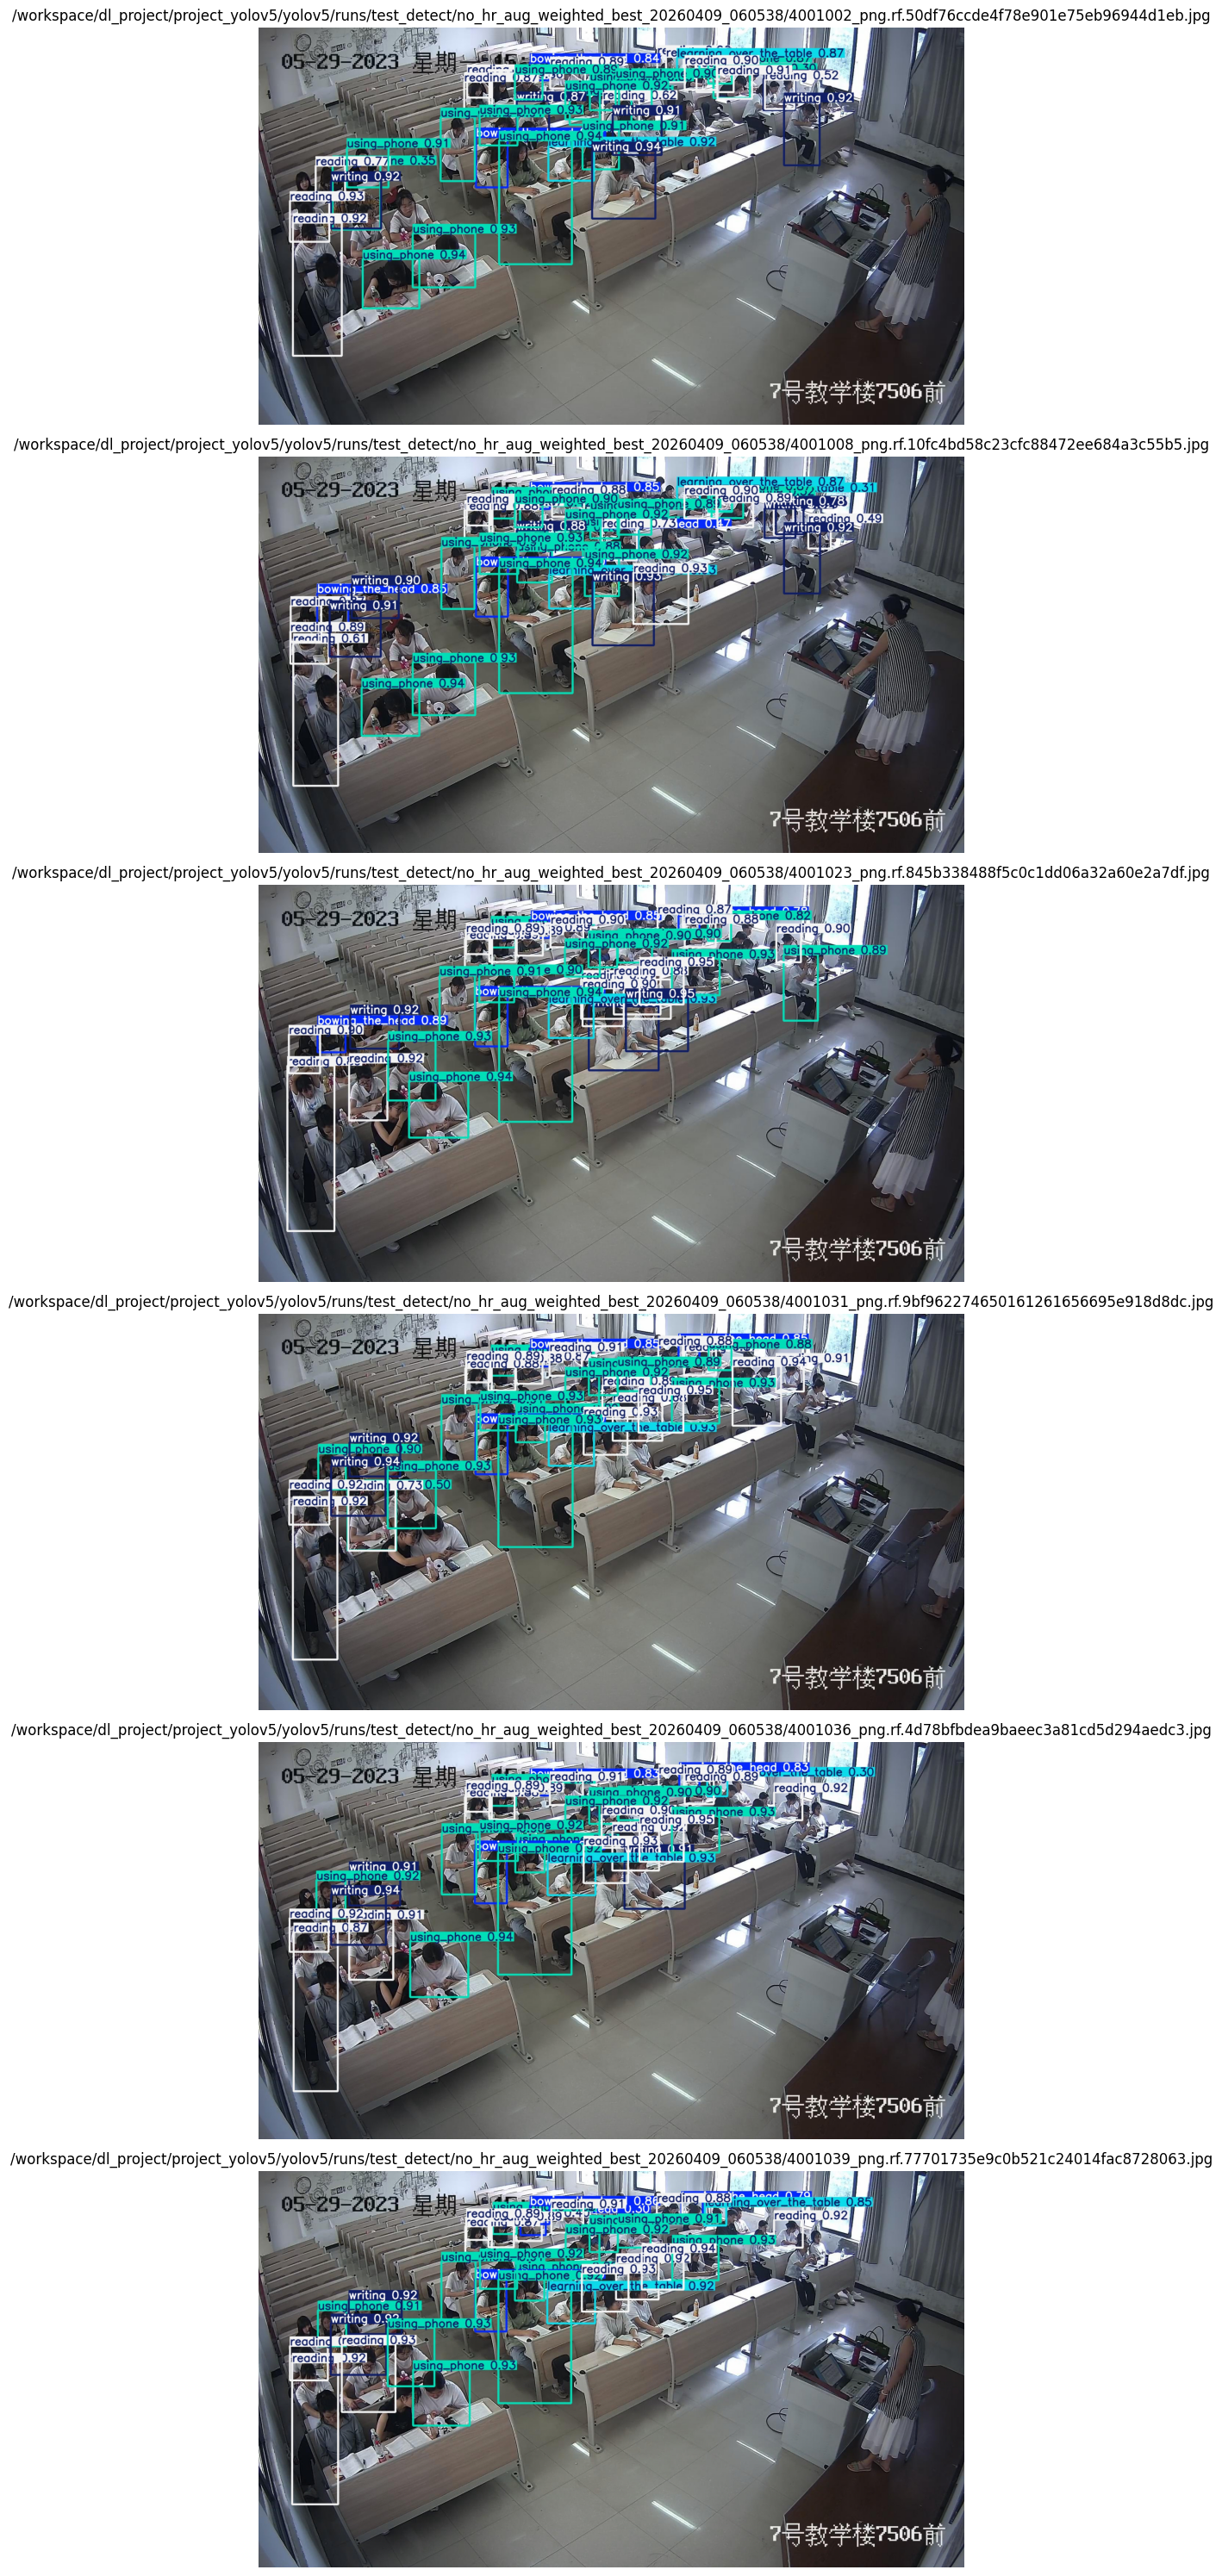

In [ ]:
image_paths = []

# 收集 detect 输出图片 / collect prediction images from detect outputs
for item in detect_results:
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        image_paths.extend(sorted(item["output_dir"].glob(ext)))

assert image_paths, "No prediction images found in runs/test_detect."

# 这里顺序展示前若干张图片 / show the first several images in order
num_show = min(6, len(image_paths))
sample_paths = image_paths[:num_show]

fig, axes = plt.subplots(num_show, 1, figsize=(12, 5 * num_show))
if num_show == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_paths):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(str(img_path))
    ax.axis("off")

plt.tight_layout()
plt.show()
